In [7]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./sonar/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

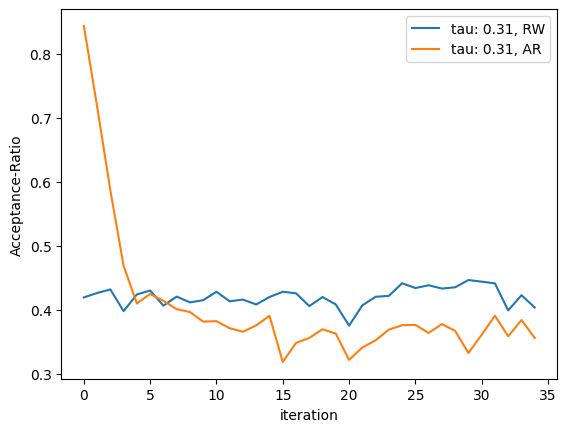

In [8]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'gamma' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)
labels=["RW", "AR"]
for _idx, l in enumerate([list_idx_rwmh, list_idx_ar]):
    for idx in l:
        plt.plot(np.mean(PKLs[idx]['res'][3], axis=[0, 2, 3]), label=f'tau: {str(PKLs[idx]['config']['tau'])[:4]}, {labels[_idx]}')
plt.ylabel("Acceptance-Ratio")
plt.xlabel("iteration")
plt.legend()
plt.savefig("AR.png")
